# Topics
#### Classifiers
No single classifier works best across all possible scenarios!
- Logistic regression
- Support vector machines
- Decision Trees

#### Trainig a supervised machine - 5 steps
- Selecting features and collecting labeled training examples
- Choosing a performance metric
- Choosing a classifier and optimization algorithm
- Evaluating the performance of the model
- Tuning the algorithm

#### Training a perceptron
#### Training a Logistic Regression
#### Using Logistic Regression API from scikit-learn
#### Regularization
#### Support Vector Machines
#### Decision Tree Learning

---

# Perceptron Models

Goals:
- build a perceptron classification model and Logistic Regression Model
- binary classification - two features and two outcomes

Data:
- Iris from sklearn.datasets
- only use two features - petal length and petal width
- only use two outcomes - flowers setosa and versicolor

#### Step 1 - Import packages

In [53]:
# import pacakges
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from mlxtend.plotting import plot_decision_regions # used to show the boundary

%matplotlib inline

#### Step 2 - Load data, separate features and outcome

In [2]:
iris = datasets.load_iris()

In [3]:
# features: petal length and petal width (cm)
X = iris.data[:, [2,3]]

# outcome
y = iris.target

print(f'Feature shape: {X.shape}')
print(f'outcome shape: {y.shape}')

print(f'feature dtype: {X.dtype}')
print(f'outcome dtype: {y.dtype}')

Feature shape: (150, 2)
outcome shape: (150,)
feature dtype: float64
outcome dtype: int64


### Step 3 - EDA
- Data is clean, don't need preprocess

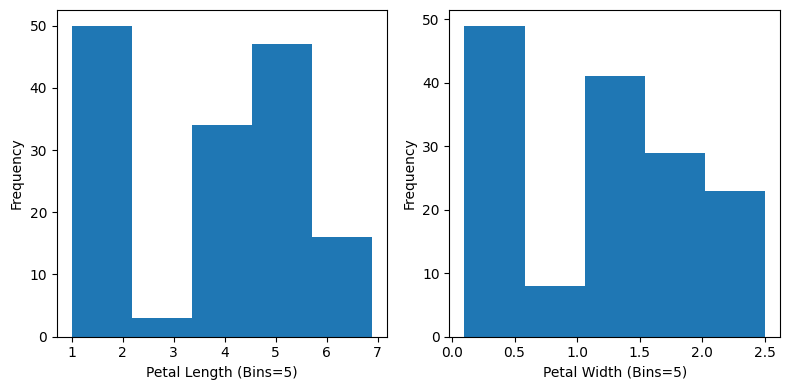

In [4]:
# review feature distribution
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].hist(X[:,0], bins=5)
ax[0].set_xlabel('Petal Length (Bins=5)')
ax[0].set_ylabel('Frequency')

ax[1].hist(X[:,1], bins=5)
ax[1].set_xlabel('Petal Width (Bins=5)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [5]:
# review outcome
pd.Series(y).value_counts()

0    50
1    50
2    50
Name: count, dtype: int64

### Step 4 - split data to train and test

In [6]:
# 30% as test, random_state=0 will produce same data set when run it again - reproducible
# stratify = y: make sure each category stays the same percentage as the origianl datasets
# train_test_split function shuffles the training datasets internally before splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    stratify=y,
                                                    random_state=0)

In [7]:
# scaling
# scaling will improve the training process during gradient descient
# StandardScaler - mean as 0, std as 1
sc = StandardScaler()
sc.fit(X_train) # fit method would estimate the mean and std
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test) # apply scaling parameters from X_train to X_test, so both data would comparable

### Step 5 - train the Perceptron model

In [ ]:
# train a perceptron model
ppn = Perceptron(eta0=0.1, # learning rate (too big - overshoot the global cost minimum, too small - require more epochs until convergence)
                 max_iter=1000,
                 random_state=1) # random_state to ensure the reproducibility
ppn.fit(X_train_std, y_train)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",1


``perceptron``
- is a linear classifier based on the classic perceptron algorithm - it is a single-layer neural network with no hidden layers an dno nonlinear activaiton in the usual sense.
- The perceptron learns a linear decision boundary by computing a weighted sum of the input features plus a bias, then classifiying based on the sign of that sum: prediction = sign(w * x + b).
- Training works by iterating over the data and only update the weights if misclassified. 

In [30]:
# fit the model
y_pred = ppn.predict(X_test_std)

### Step 6 - Evaluate Model Performance

In [31]:
# manually calculate error and accuracy
error = (y_test != y_pred).sum() / len(y_pred)
accuracy = 1 - error
print(f'Perceptron Model Accuracy: {accuracy:.3f}')

# sklearn has the metrics
print(f'accuracy: {accuracy_score(y_test, y_pred):.3f}')

# each classifier in scikit-learn has a score method
print(f'accuracy: {ppn.score(X_test_std, y_test):.3f}')

Perceptron Model Accuracy: 0.956
accuracy: 0.956
accuracy: 0.956


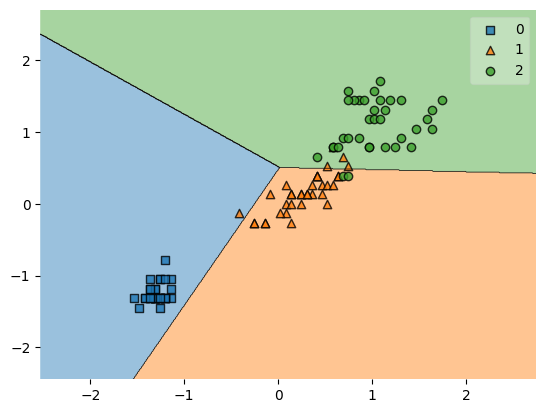

In [33]:
# see the boundary for train data
plot_decision_regions(X=X_train_std, y=y_train, clf=ppn);

The three flowers can't be separate by linear model, becaue perceptron learning algorithm only has a convergence guarantee when the classes are linearly separable.

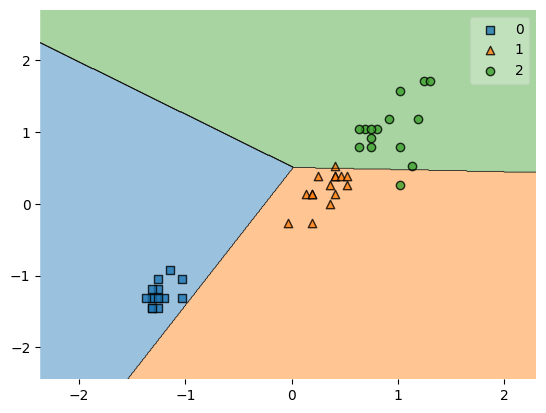

In [34]:
# see the boundary for train data
plot_decision_regions(X=X_test_std, y=y_test, clf=ppn);

The perceptron algorithm actually did a great job on both training and test dataset.

# Logistic Regression Model

``What is Logistic Regression``
- linear model for classification, to predict a binary outcome.
- The sigmoid maps any real number into the range(0,1), so the output as P(y=1|x). If the probabiliyt exceeds a threshold (0.5 by default), we predict class 1, otherwise class 0.
- The logistic regression is a linear model/linear classifier because its decision boundar is linear in the input features, even though it applis a nonlinear sigmoid to produce probabilities. The boundary lives where P(y=1/x) = 0.5, which occurs exactly when w * x + b = 0

``What is the objective of Logitstic Regression``
- Maximize the likelihood (or minimize the negative log function) - applying the log function reduces the potential for numerical underflow, this can occur if the likelihoods are very small.

``how to minimize the negative log function``
- gradient descent, it comes as the same as the linear gradient descent

### Logistic Regression Cost Function

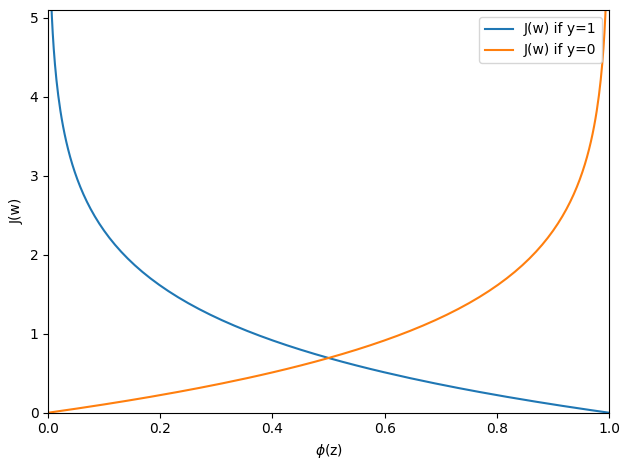

In [42]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# y = 1
def cost_1(z):
    return -np.log(sigmoid(z))

# y = 0
def cost_2(z):
    return -np.log(1 - sigmoid(z))

z = np.arange(-10,10,0.1)
phi_z = sigmoid(z)
c1 = [cost_1(x) for x in z]
plt.plot(phi_z, c1, label='J(w) if y=1')

c2 = [cost_2(x) for x in z]
plt.plot(phi_z, c2, label='J(w) if y=0')
plt.ylim(0.0, 5.1)
plt.xlim([0,1])
plt.xlabel('$\phi$(z)')
plt.ylabel('J(w)')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

We can see if the actual class is 1, and our prediciton is 1, the cost is 0. As the prediciton probability increase from 0 to 1, the cost continually decrease. 

if the actual class is 0, and our prediction (the likelihood to be 1) is 0, the cost is 0.

### Logistic Regression from Scratch

In [ ]:
# build the logistic regresson class
class LogisticRegressionGD():
    def __init__(self, eta, n_iter, random_state):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    # update the weights and track loss
    def fit(self, X, y):
        rgn = np.random.RandomState(self.random_state)
        self.w_ = rgn.normal(loc=0.0, scale=0.1,
                             size = 1 + X.shape[1]) # initialize W with bias
        self.cost_ = []

        for _ in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            error = y - output

            self.w_[1:] += self.eta * X.T.dot(error) # update weights, same as the linear Gradient Descent
            self.w_[0] += self.eta * error.sum() # update the bias

            cost = -y.dot(np.log(output)) - (1 - y).dot(np.log(1 - output)) # Logistic Regression Loss
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        return X.dot(self.w_[1:]) + self.w_[0]

    def activation(self, z): # sigmoid function
        return 1 / (1 + np.exp(-np.clip(z,-250,250)))

    def predict(self, X): # if sigmoid function >=0.5
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

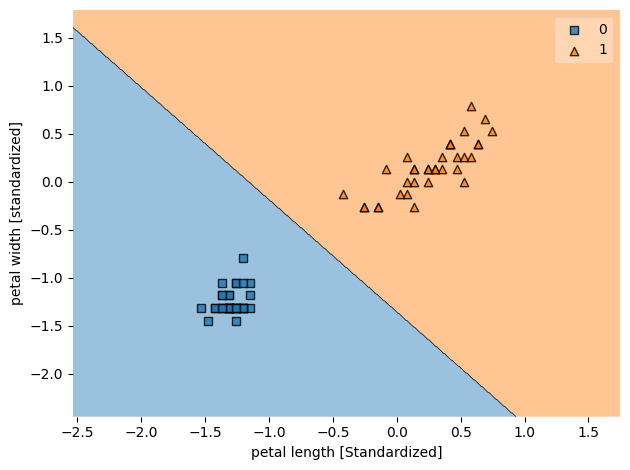

In [57]:
# logistic regression only for binary classes, only pull class: 0, 1
X_train_01_subset = X_train_std[(y_train==0) | (y_train==1)]
y_train_01_subset = y_train[(y_train==0) | (y_train==1)]
lrgd = LogisticRegressionGD(
    eta = 0.05,
    n_iter=1000,
    random_state=1)
lrgd.fit(X_train_01_subset,
         y_train_01_subset)
plot_decision_regions(X_train_01_subset, y_train_01_subset, lrgd) # boundary
plt.xlabel('petal length [Standardized]')
plt.ylabel('petal width [standardized]')
plt.tight_layout()
plt.show()

### Logistic regression model wiht scikit-learn
- it can train multiple classes automatically
- C is the inverse of regularization

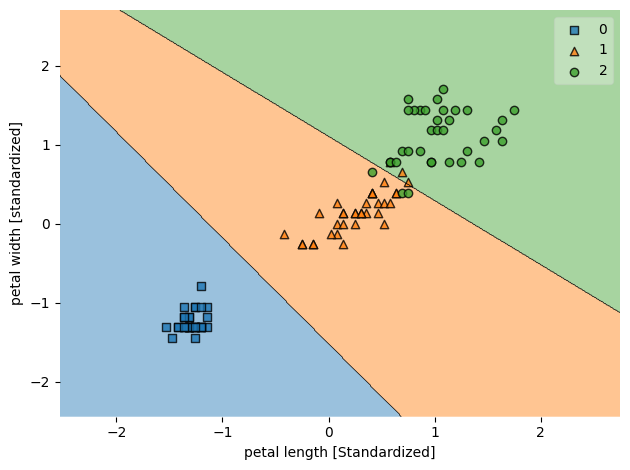

In [76]:
lr = LogisticRegression(
    C=100.00, solver='lbfgs', random_state = 1 # C: inverse of the regularization
)
lr.fit(X_train_std, y_train)
plot_decision_regions(X_train_std, y_train, lr)
plt.xlabel('petal length [Standardized]')
plt.ylabel('petal width [standardized]')
plt.tight_layout()
plt.show()

In [ ]:
# .predict_proba() would return the probabily of each class for one sample
lr.predict_proba(X_test_std[:3, :])

array([[9.82188900e-14, 1.20146144e-04, 9.99879854e-01],
       [5.24600667e-09, 5.18198513e-02, 9.48180143e-01],
       [9.99008489e-01, 9.91510690e-04, 4.31716334e-14]])

In [ ]:
# .argmax(axis=1): return the class (actually return the location)
lr.predict_proba.predict_proba(X_test_std[:3, :]).argmax(axis=1)

array([2, 2, 0])

In [ ]:
# .predict(): automatically return the class
lr.predict(X_test_std[:3, :])

array([2, 2, 0])

### Regularization (L2 - Ridge)
- ``Overfitting`` (high variance) is a a model performs well on traiing data but not generalize well on unseen data (test data).
- ``Underfitting`` (high bias) means model is not complex enough to capture the pattern in the training data well and theere fore also suffers from lowe performance on unseen data.
- one way of finding a good bias-variance tradeoff is to tune the complexity of the model via regularization.
- ``Regularization`` is another reason why feature scaling such as standardization is important. For regularization to work properly, we need to ensure that all our features are on comparable scales.
- ``C`` is the inverse of regularization strength, High C means low regularization.

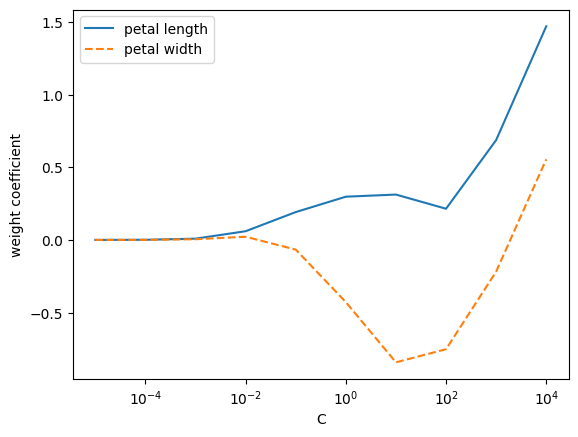

In [82]:
weights, params = [], []
for c in np.arange(-5,5):
    lr = LogisticRegression(C = 10.**c, random_state=1, solver='lbfgs')
    lr.fit(X_train_std, y_train)
    weights.append(lr.coef_[1])
    params.append(10.**c)

weights = np.array(weights)
plt.plot(params, weights[:, 0], label='petal length')
plt.plot(params, weights[:, 1], linestyle='--', label='petal width')
plt.ylabel('weight coefficient')
plt.xlabel('C')
plt.legend(loc='upper left')
plt.xscale('log')
plt.show()

As we can see as C increases, the weights stay aways from 0. otherwise weight becomes 0.

# Support Vector Machine
- the optimizatin objective is to maximize the margin. The margin is defined as the distance between the separating hyperplane (decision boundary) and the training examples that are closest to this hyperplane, which are the so called support vectors.
- Test kernel, C, and gamma

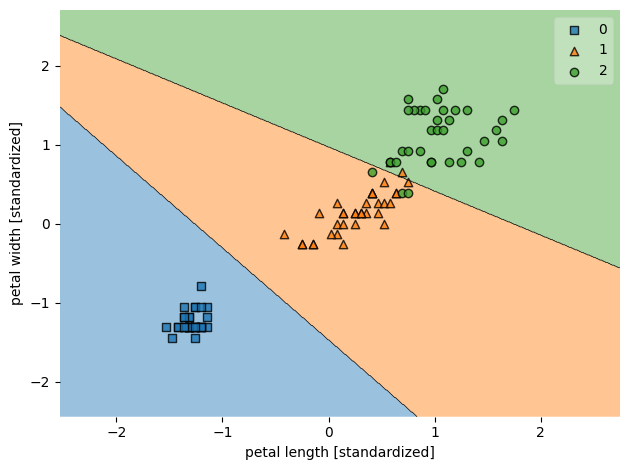

In [89]:
# SVC - kernel as 'linear'
from sklearn.svm import SVC
svm = SVC(kernel='linear', C=1.0, random_state=1, gamma=1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_train_std, y_train, svm)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.tight_layout()
plt.show()

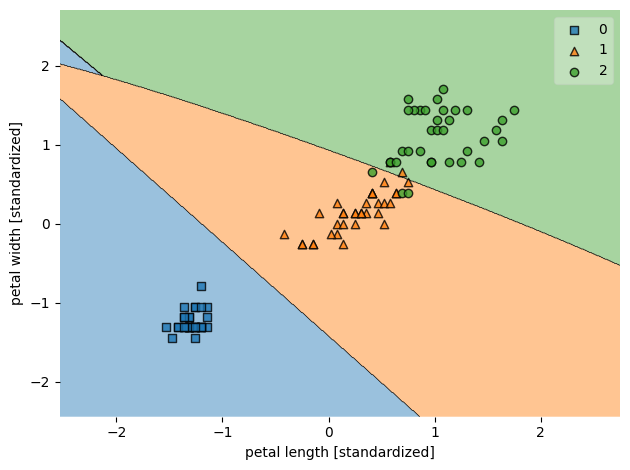

In [ ]:
# SVC - kernel as 'rbf' Radial Basis Function, incrase C
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=10.0, random_state=1, gamma=0.1)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_train_std, y_train, svm)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.tight_layout()
plt.show()

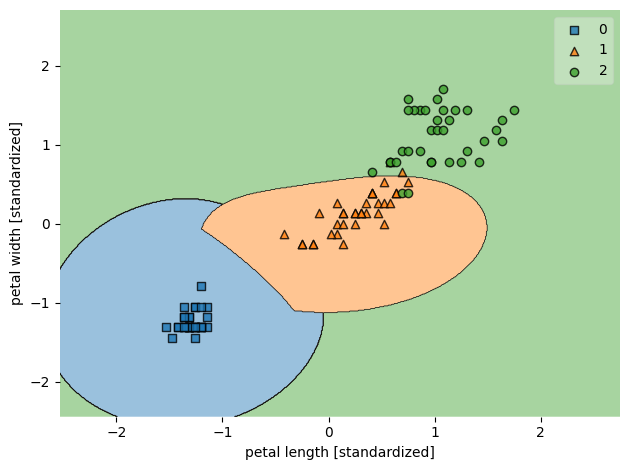

In [ ]:
# SVC - kernel as 'rbf' Radial Basis Function, increase gamma
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=10.0, random_state=1, gamma=1.0)
svm.fit(X_train_std, y_train)
plot_decision_regions(X_train_std, y_train, svm)
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.tight_layout()
plt.show()